## Traditional ML: Random Forest Regressor for Object Localization

In [ ]:
import os
import joblib
import numpy                 as np
import matplotlib.pyplot     as plt
import matplotlib.patches    as patches
from sklearn.decomposition   import PCA
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics         import mean_squared_error, make_scorer

In [2]:
X = np.load('../preprocessed_data/images.npy')
Y = np.load('../preprocessed_data/bboxes.npy')
print(f'Images: {X.shape}, Bboxes: {Y.shape}')

Images: (3686, 224, 224, 3), Bboxes: (3686, 4)


In [3]:
X_flat = X.reshape(len(X), -1)

idx = np.arange(len(X))
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42)

X_train     = X_flat[train_idx]
X_test      = X_flat[test_idx]
y_train     = Y[train_idx]
y_test      = Y[test_idx]
X_test_imgs = X[test_idx]

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 2948 samples | Test: 738 samples


## Hyperparameter Search

PCA and Random Forest are combined in a Pipeline so PCA is fit only on training folds during cross-validation, preventing data leakage. RandomizedSearchCV samples 20 combinations and scores each using mean IoU.

In [4]:
def iou(actual, pred):
    x1, y1, w1, h1 = actual
    x2, y2, w2, h2 = pred
    w_i = min(x1 + w1, x2 + w2) - max(x1, x2)
    h_i = min(y1 + h1, y2 + h2) - max(y1, y2)
    if w_i <= 0 or h_i <= 0:
        return 0.0
    intersection = w_i * h_i
    union = w1 * h1 + w2 * h2 - intersection
    return intersection / union

def mean_iou(y_true, y_pred):
    return np.mean([iou(y_true[i], y_pred[i]) for i in range(len(y_true))])

iou_scorer = make_scorer(mean_iou, greater_is_better=True)

In [5]:
pipeline = Pipeline([
    ('pca', PCA(random_state=42)),
    ('rf',  RandomForestRegressor(random_state=42))
])

param_dist = {
    'pca__n_components':    [100, 200, 300],
    'rf__n_estimators':     [100, 200, 300],
    'rf__max_depth':        [None, 10, 20, 30],
    'rf__min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring=iou_scorer,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print(f'Best params: {search.best_params_}')
print(f'Best CV IoU: {search.best_score_:.3f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'rf__n_estimators': 200, 'rf__min_samples_leaf': 2, 'rf__max_depth': None, 'pca__n_components': 100}
Best CV IoU: 0.374


## Evaluation

In [6]:
best = search.best_estimator_

y_pred_train = best.predict(X_train)
y_pred_test  = best.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse  = mean_squared_error(y_test,  y_pred_test)
train_iou = mean_iou(y_train, y_pred_train)
test_iou  = mean_iou(y_test,  y_pred_test)

print(f'Train — MSE: {train_mse:.2f} | IoU: {train_iou:.3f}')
print(f'Test  — MSE: {test_mse:.2f} | IoU: {test_iou:.3f}')

Train — MSE: 258.76 | IoU: 0.588
Test  — MSE: 1130.66 | IoU: 0.373


## Predictions Visualization

Green = actual bounding box, Red = predicted bounding box.

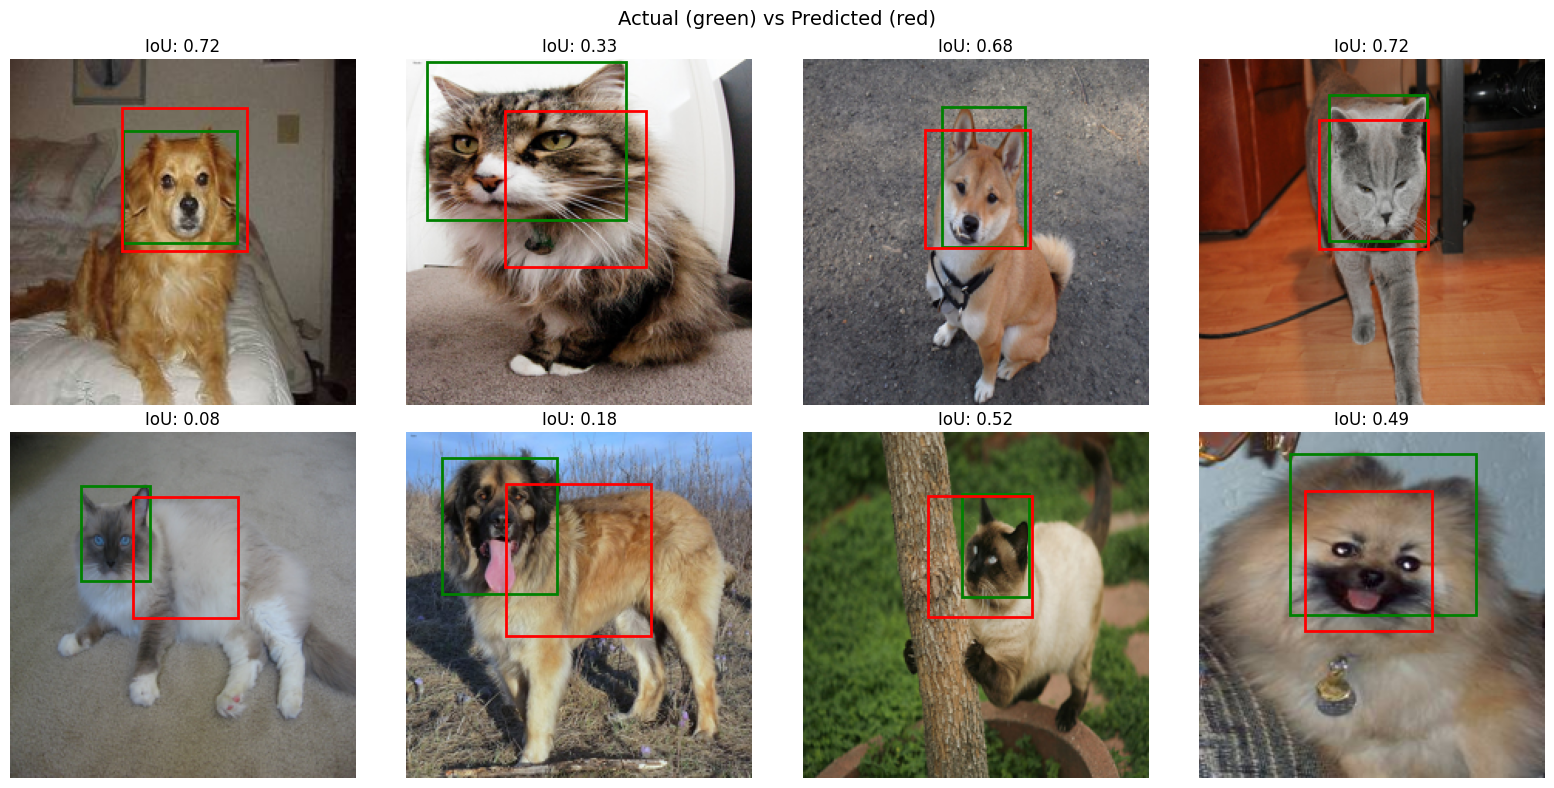

In [7]:
fig, axes  = plt.subplots(2, 4, figsize=(16, 8))
sample_idx = np.random.choice(len(X_test_imgs), 8, replace=False)

for ax, i in zip(axes.flatten(), sample_idx):
    ax.imshow(X_test_imgs[i])
    x, y, w, h = y_test[i]
    ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='g', facecolor='none'))
    px, py, pw, ph = y_pred_test[i]
    ax.add_patch(patches.Rectangle((px, py), pw, ph, linewidth=2, edgecolor='r', facecolor='none'))
    ax.set_title(f'IoU: {iou(y_test[i], y_pred_test[i]):.2f}')
    ax.axis('off')

plt.suptitle('Actual (green) vs Predicted (red)', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
X_train_raw = X.reshape(len(X), -1)[train_idx]

pca_best = PCA(n_components=100, random_state=42)
X_train_best = pca_best.fit_transform(X_train_raw)

rf_best = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, max_depth=None, random_state=42)
rf_best.fit(X_train_best, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(pca_best, 'models/pca.joblib')
joblib.dump(rf_best,  'models/random_forest.joblib')
print('Saved pca.joblib and random_forest.joblib to machine_learning/models/')

Saved pca.joblib and random_forest.joblib to machine_learning/models/
